<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/kmeans_clustering_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# K-Means Clustering Project (Kaggle Dataset)

**Dataset:** Mall Customers Dataset (Kaggle)

Download:
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

This notebook covers:
1. Load Dataset
2. Exploratory Data Analysis
3. Feature Selection
4. Elbow Method
5. K-Means Clustering
6. Cluster Visualization
7. Cluster Interpretation


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns',None)


## Load Dataset

In [ ]:

df = pd.read_csv('Mall_Customers.csv')

df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:

df.shape


(200, 5)

In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Basic Data Analysis

In [ ]:

df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:

df.isnull().sum()


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

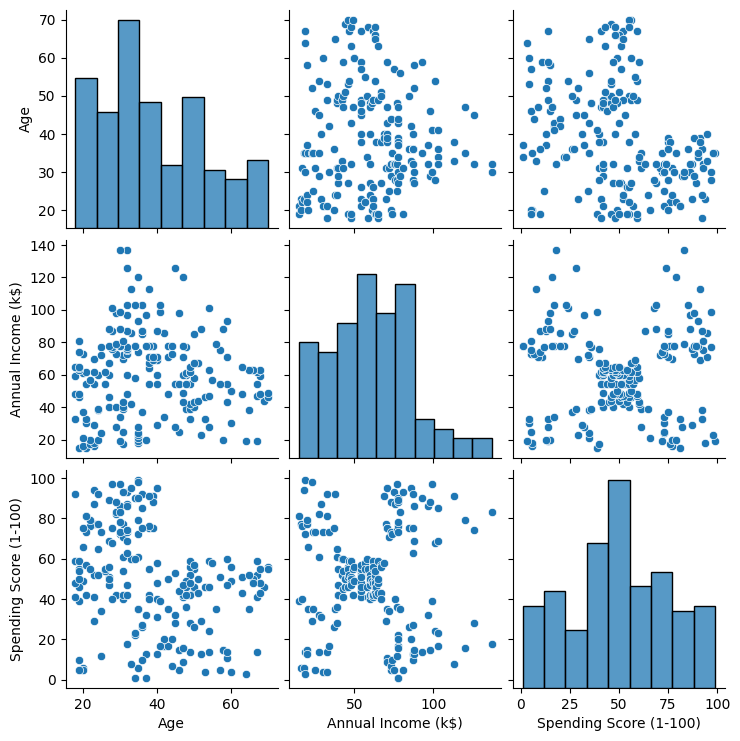

In [ ]:

sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)']])
plt.show()


## Select Features for Clustering

In [ ]:

X = df[['Annual Income (k$)','Spending Score (1-100)']]

X.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Feature Scaling

In [ ]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## Elbow Method

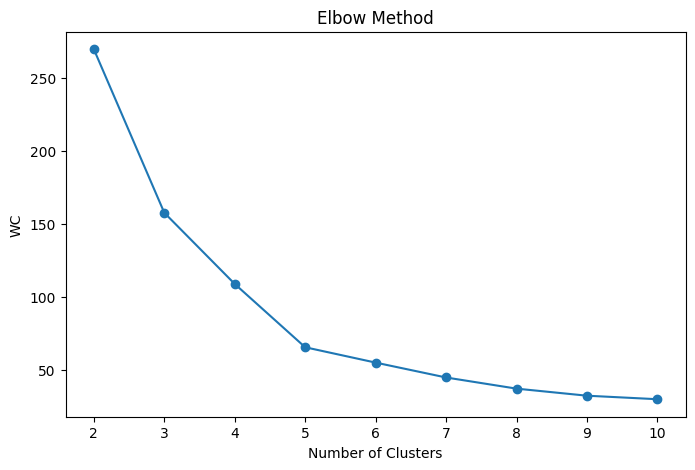

In [ ]:

wc = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wc.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11),wc,marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WC')
plt.title('Elbow Method')

plt.show()



Choose K based on the elbow point.

For this dataset K=5 is commonly used.


## Train K-Means Model

In [ ]:

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

## Cluster Distribution

## Cluster Centers

In [ ]:

centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income','Spending Score']
)

centers_df


,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Visualize Clusters

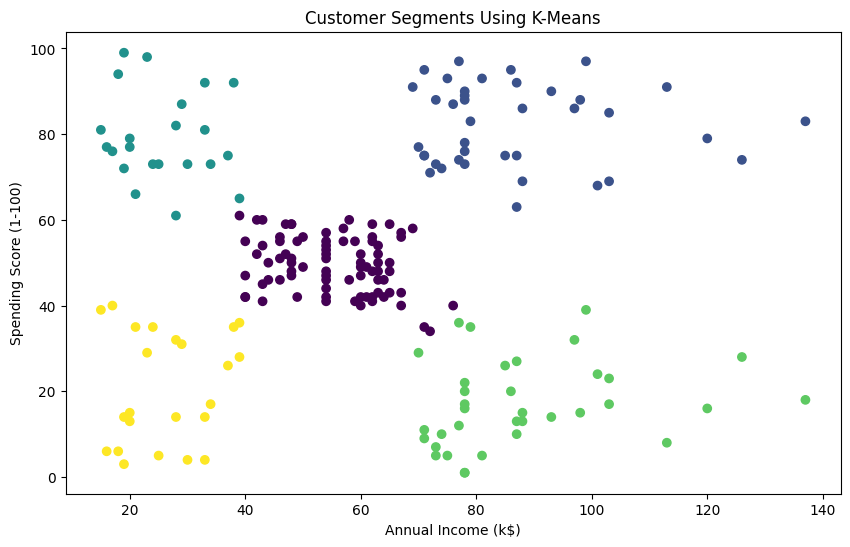

In [ ]:

plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments Using K-Means')

plt.show()


## Business Interpretation


Possible cluster interpretations:

- Cluster 0 → High Income, High Spending
- Cluster 1 → Low Income, Low Spending
- Cluster 2 → High Income, Low Spending
- Cluster 3 → Low Income, High Spending
- Cluster 4 → Average Customers

Use these clusters for targeted marketing campaigns.


## Student Tasks


1. Load the dataset.
2. Check shape and data types.
3. Check missing values.
4. Perform EDA.
5. Select clustering variables.
6. Scale the data.
7. Apply Elbow Method.
8. Find optimal K.
9. Train K-Means model.
10. Assign cluster labels.
11. Visualize clusters.
12. Interpret customer segments.
13. Try K=3, K=4, K=6 and compare.
14. Use Age along with Income and Spending Score.
15. Create a business report.
